In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
base_path = "/content/drive/MyDrive/finalaipro"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 40  


In [ ]:
# ---  DATA AUGMENTATION (The "Force Multiplier") ---
# This is crucial for your small dataset of 500 images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test should only be rescaled
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("\n Loading Datasets...")
train_gen = train_datagen.flow_from_directory(
    os.path.join(base_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_path, "validate"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_path, "test"),
    target_size=IMG_SIZE,
    batch_size=1, # One at a time for precise testing
    class_mode="binary",
    shuffle=False
)


 Loading Datasets...
Found 304 images belonging to 2 classes.
Found 90 images belonging to 2 classes.
Found 94 images belonging to 2 classes.


In [ ]:
# ---  THE MODEL (Transfer Learning) ---
#
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep the "brain" frozen initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(), # Added for training stability
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# --- 4. SMART CALLBACKS ---
my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ModelCheckpoint('ai_vs_real_best.h5', save_best_only=True)
]

In [7]:
# --- 5. INITIAL TRAINING ---
print("\n Stage 1: Training the Head...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS // 2,
    callbacks=my_callbacks
)


 Stage 1: Training the Head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4732 - loss: 1.0528

19/19 ━━━━━━━━━━━━━━━━━━━━ 124s 6s/step - accuracy: 0.4757 - loss: 1.0488 - val_accuracy: 0.6000 - val_loss: 0.6542
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6738 - loss: 0.7132

19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6737 - loss: 0.7141 - val_accuracy: 0.7222 - val_loss: 0.5652
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7372 - loss: 0.6016

...

19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7938 - loss: 0.4242 - val_accuracy: 0.8444 - val_loss: 0.3652
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8202 - loss: 0.3457

19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8213 - loss: 0.3455 - val_accuracy: 0.8556 - val_loss: 0.3506
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.8782 - loss: 0.3216 - val_accuracy: 0.8444 - val_loss: 0.3532
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8848 - loss: 0.2796 - val_accuracy: 0.8444 - val_loss: 0.3580
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8551 - loss: 0.3238 - val_accuracy: 0.8444 - val_loss: 0.3522
Epoch 14/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8839 - loss: 0.2451

19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8836 - loss: 0.2468 - val_accuracy: 0.8556 - val_loss: 0.3456
Epoch 15/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8735 - loss: 0.2974

19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8739 - loss: 0.2970 - val_accuracy: 0.8444 - val_loss: 0.3429
Epoch 16/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8806 - loss: 0.2664 - val_accuracy: 0.8444 - val_loss: 0.3567
Epoch 17/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.8133 - loss: 0.3470 - val_accuracy: 0.8667 - val_loss: 0.3608
Epoch 18/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8669 - loss: 0.2743 - val_accuracy: 0.8556 - val_loss: 0.3502
Epoch 19/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9061 - loss: 0.2334

19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9057 - loss: 0.2336 - val_accuracy: 0.8333 - val_loss: 0.3394
Epoch 20/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8522 - loss: 0.3568 - val_accuracy: 0.8444 - val_loss: 0.3526


In [10]:
# ---  STAGE 2: FINE-TUNING (To boost accuracy beyond 85%) ---
# We unfreeze the top layers of the base model to learn specific AI textures
print("\n Stage 2: Fine-Tuning...")
base_model.trainable = True
# Only train from the 100th layer onwards to avoid breaking the features
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Tiny LR for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=my_callbacks
)


 Stage 2: Fine-Tuning...
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8713 - loss: 0.3008

19/19 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8713 - loss: 0.3021 - val_accuracy: 0.8444 - val_loss: 0.3348
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8859 - loss: 0.3104

19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.8861 - loss: 0.3102 - val_accuracy: 0.8556 - val_loss: 0.3321
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8775 - loss: 0.3101

19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8787 - loss: 0.3072 - val_accuracy: 0.8667 - val_loss: 0.3263
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8568 - loss: 0.3281

19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.8585 - loss: 0.3245 - val_accuracy: 0.8556 - val_loss: 0.3077
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8580 - loss: 0.3671

19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8585 - loss: 0.3636 - val_accuracy: 0.8667 - val_loss: 0.3010
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9007 - loss: 0.2615 - val_accuracy: 0.8667 - val_loss: 0.3032
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.9112 - loss: 0.2250 - val_accuracy: 0.8778 - val_loss: 0.3012
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9414 - loss: 0.1921

19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.9404 - loss: 0.1931 - val_accuracy: 0.8667 - val_loss: 0.2974
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9146 - loss: 0.2564

19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9143 - loss: 0.2547 - val_accuracy: 0.8667 - val_loss: 0.2915
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9238 - loss: 0.1576

19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9235 - loss: 0.1590 - val_accuracy: 0.8778 - val_loss: 0.2857


In [11]:

# --- 7. EVALUATION ---
print("\n Final Evaluation on Test Set...")
test_gen.reset()
predictions = model.predict(test_gen)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['AI', 'Real']))


 Final Evaluation on Test Set...
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          AI       0.82      0.98      0.89        46
        Real       0.97      0.79      0.87        48

    accuracy                           0.88        94
   macro avg       0.90      0.88      0.88        94
weighted avg       0.90      0.88      0.88        94



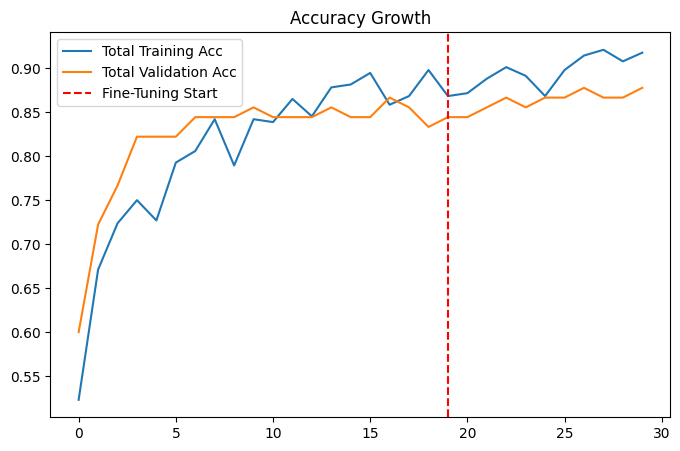

In [12]:
# --- 8. VISUALIZE RESULTS ---
#
def plot_results(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']

    plt.figure(figsize=(8, 5))
    plt.plot(acc, label='Total Training Acc')
    plt.plot(val_acc, label='Total Validation Acc')
    plt.axvline(x=len(h1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-Tuning Start')
    plt.title('Accuracy Growth')
    plt.legend()
    plt.show()

plot_results(history, history_finetune)

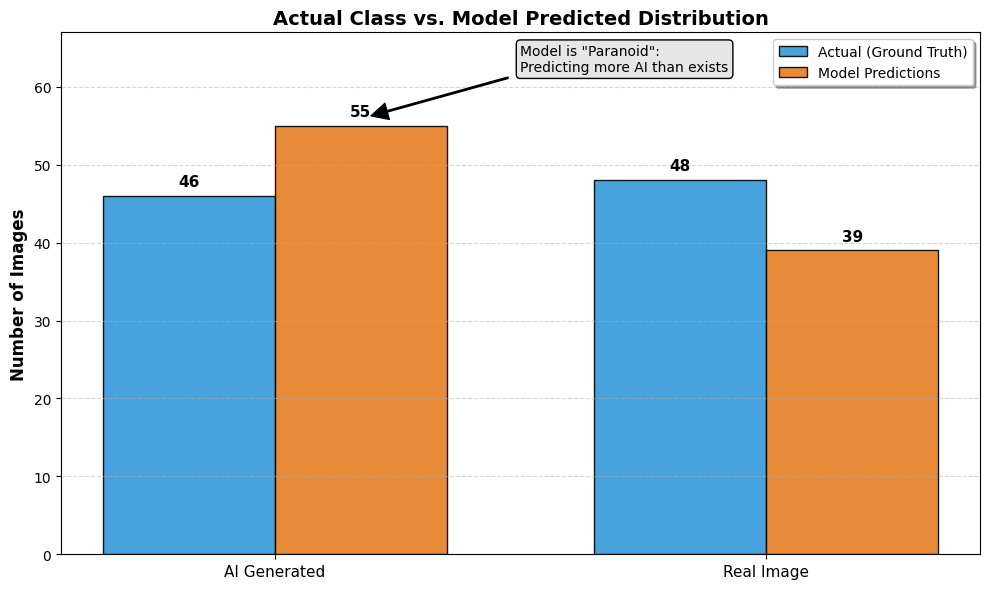

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Setup
labels = ['AI Generated', 'Real Image']
actual_counts = [46, 48]
predicted_counts = [55, 39]

x = np.arange(len(labels))  # Label locations
width = 0.35               # Width of the bars

# 2. Plotting
plt.figure(figsize=(10, 6))
bar1 = plt.bar(x - width/2, actual_counts, width, label='Actual (Ground Truth)',
               color='#3498db', alpha=0.9, edgecolor='black')
bar2 = plt.bar(x + width/2, predicted_counts, width, label='Model Predictions',
               color='#e67e22', alpha=0.9, edgecolor='black')

# 3. Aesthetics
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Actual Class vs. Model Predicted Distribution', fontsize=14, fontweight='bold')
plt.xticks(x, labels, fontsize=11)
plt.ylim(0, max(actual_counts + predicted_counts) + 12) # Leave space for text labels
plt.legend(frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Adding Value Labels on Top of Bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

add_labels(bar1)
add_labels(bar2)

# 5. Adding a Mentorship Note (Explaining the gap)
plt.annotate('Model is "Paranoid":\nPredicting more AI than exists',
             xy=(0.18, 56), xytext=(0.5, 62),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, bbox=dict(boxstyle="round", fc="0.9"))

plt.tight_layout()
plt.show() # Use plt.show() for immediate view in Google Colab

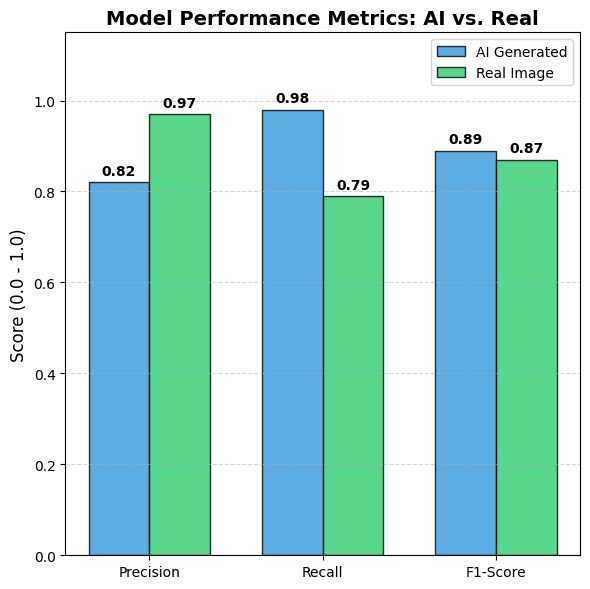

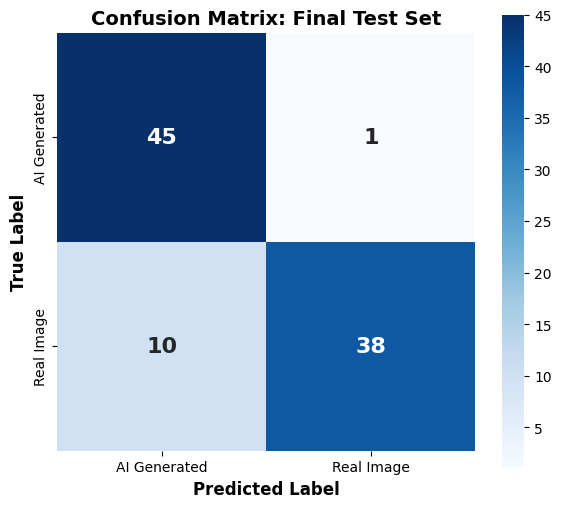

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- DATA FROM CLASSIFICATION REPORT ---
categories = ['Precision', 'Recall', 'F1-Score']
ai_metrics = [0.82, 0.98, 0.89]
real_metrics = [0.97, 0.79, 0.87]

x = np.arange(len(categories))
width = 0.35

# 1. Plotting the Metrics Bar Chart
plt.figure(figsize=(6, 6))
bar1 = plt.bar(x - width/2, ai_metrics, width, label='AI Generated', color='#3498db', alpha=0.8, edgecolor='black')
bar2 = plt.bar(x + width/2, real_metrics, width, label='Real Image', color='#2ecc71', alpha=0.8, edgecolor='black')

plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.title('Model Performance Metrics: AI vs. Real', fontsize=14, fontweight='bold')
plt.xticks(x, categories)
plt.ylim(0, 1.15)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Function to add values on top of bars automatically
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(bar1)
autolabel(bar2)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
# Correct Layout for Confusion Matrix:
# Row 0: Actual AI [True AI (TP), False Real (FN)]
# Row 1: Actual Real [False AI (FP), True Real (TN)]
cm = np.array([[45, 1],
               [10, 38]])

labels = ['AI Generated', 'Real Image']

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            square=True, cbar_kws={"shrink": .8},
            annot_kws={"size": 16, "weight": "bold"})

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Final Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Saving ai-generated-animal-crossbreeds-02.jpg to ai-generated-animal-crossbreeds-02.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step


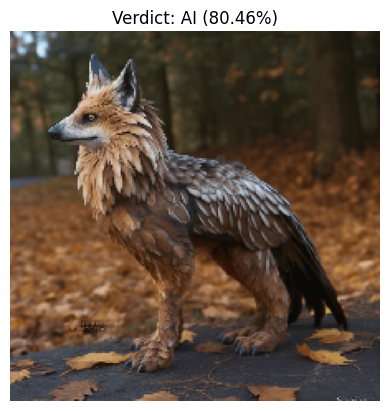

In [26]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Load your saved model
model = tf.keras.models.load_model('ai_vs_real_best.h5')

def test_new_image():
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 2. Preprocessing
        img = image.load_img(fn, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0  # Crucial: Must match training normalization

        # 3. Prediction
        prediction = model.predict(img_array)[0][0]

        # 4. Result
        label = "REAL" if prediction > 0.5 else "AI"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        plt.imshow(img)
        plt.title(f"Verdict: {label} ({confidence*100:.2f}%)")
        plt.axis('off')
        plt.show()

test_new_image()

Saving OIP.jpg to OIP.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step


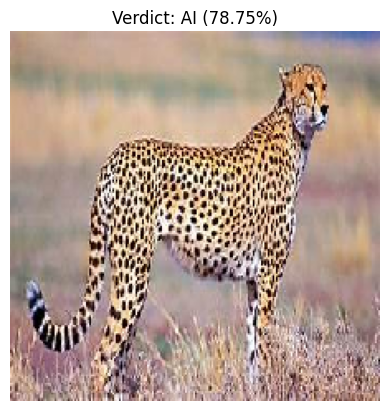

In [27]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Load your saved model
model = tf.keras.models.load_model('ai_vs_real_best.h5')

def test_new_image():
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 2. Preprocessing
        img = image.load_img(fn, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0  # Crucial: Must match training normalization

        # 3. Prediction
        prediction = model.predict(img_array)[0][0]

        # 4. Result
        label = "REAL" if prediction > 0.5 else "AI"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        plt.imshow(img)
        plt.title(f"Verdict: {label} ({confidence*100:.2f}%)")
        plt.axis('off')
        plt.show()

test_new_image()

Saving GettyImages-1145794687.jpg to GettyImages-1145794687.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


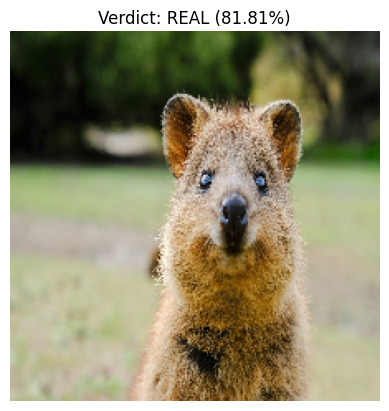

In [28]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Load your saved model
model = tf.keras.models.load_model('ai_vs_real_best.h5')

def test_new_image():
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 2. Preprocessing
        img = image.load_img(fn, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0  # Crucial: Must match training normalization

        # 3. Prediction
        prediction = model.predict(img_array)[0][0]

        # 4. Result
        label = "REAL" if prediction > 0.5 else "AI"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        plt.imshow(img)
        plt.title(f"Verdict: {label} ({confidence*100:.2f}%)")
        plt.axis('off')
        plt.show()

test_new_image()